In [1]:
import os
import sys
import glob
import logging
import json
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

%load_ext autoreload
%autoreload 2
import computervision
from computervision.dentex import Dentex
from computervision.imageproc import ImageData, is_image
from computervision.imageproc import enclosing_box, xywh2xyxy, xyxy2xywh, clipxywh, flatten

# Print version info
print(f'Package version: {computervision.__version__}')
print(f'Python version:  {sys.version}')

Package version: v0.0.2
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [14]:
# Function to plot an image with the bounding boxes
def plot_boxes(image, box_list, ax, label_list=None, color=None, cmap=None):
    offset_xy = (10, 80)
    # Take a ratio that looks good
    offset = (image.shape[1]*offset_xy[0]/2500,
              image.shape[0]*offset_xy[1]/1250)
    if color is None:
        # If no color is provided, color each box in a different color
        color_list = list(plt.cm.rainbow(np.linspace(0, 1, len(box_list))))
    else:
        color_list = [color]*len(box_list)
    ax.set(xticks=[], yticks=[])
    ax.imshow(image, cmap=cmap)
    # Loop over the bounding boxes
    for b, box in enumerate(box_list):
        rect = Rectangle(xy=(box[0], box[1]),
                         width=box[2],
                         height=box[3],
                         linewidth=2.0,
                         edgecolor=color_list[b],
                         facecolor='none',
                         alpha=0.7)
        ax.add_patch(rect)
        if label_list is not None:
            ax.text(x=box[0]+offset[0], y=box[1]+offset[1], s=label_list[b], color=color_list[b], fontsize=10)
    return ax

/app/data_model


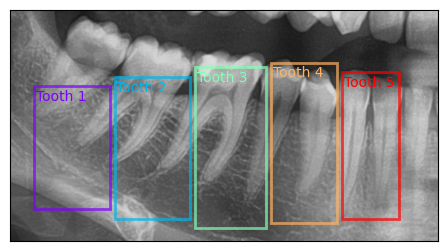

In [21]:
# Load the image
data_dir = os.environ.get('DATA')
print(data_dir)
image_file_name = 'Teeth.png'
image_file = os.path.join(data_dir, image_file_name)
im = ImageData().load_image(image_file)
y_lim, x_lim = im.shape[:2]

# Save the overlay
overlay_figure_name = f'{os.path.splitext(image_file_name)[0]}_boxes.png'
overlay_file = os.path.join(data_dir, overlay_figure_name)

bboxes_xyxy = [[25, 80, 105, 210], 
               [110, 70, 190, 220], 
               [195, 60, 270, 230], 
               [275, 55, 345, 225], 
               [350, 65, 410, 220]]

bboxes_xywh = [xyxy2xywh(bbox) for bbox in bboxes_xyxy]

labels = ['Tooth 1', 'Tooth 2', 'Tooth 3', 'Tooth 4', 'Tooth 5']

# Create the figure
fig, ax = plt.subplots(figsize=(6, 3))
ax = plot_boxes(image=im, ax=ax, box_list=bboxes_xywh, label_list=labels, color=None)

# Save the overlay figure
plt.savefig(overlay_file, bbox_inches='tight')
plt.show()